[5, 13, 23, 33, 40, 47]


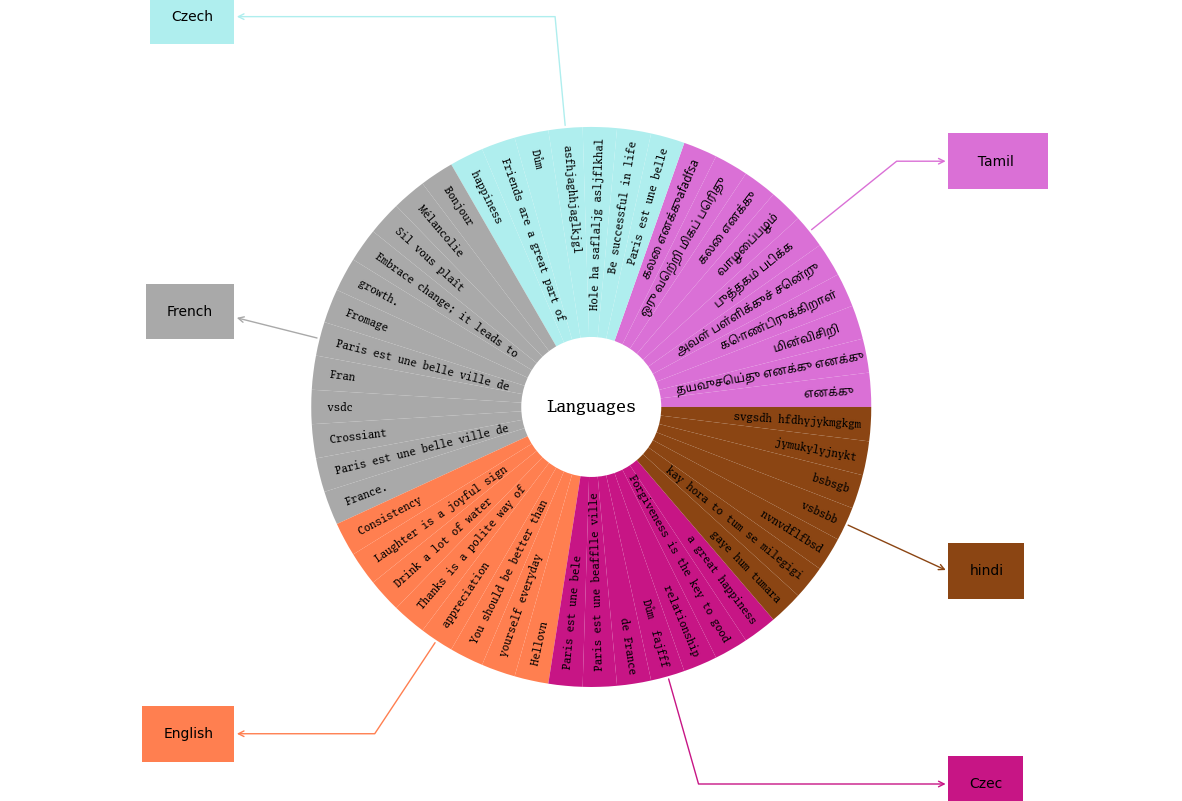

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
from matplotlib import font_manager as fm
import matplotlib.patches as patches
import random

def giveFig(wedge1, fileName, whitey=False, label12=False, lw=1, dpi1=300,l=7.2,b=7.2):
    if whitey==False:
        lw = 0

    def get_column_colors(categories, ask_user=False):
        available_colors = list(mcolors.CSS4_COLORS.keys())
        column_colors = []
        for i, category in enumerate(categories):
            if ask_user:
                print(f"\nChoose a color for column '{category}':")
                print("\nAvailable colors:", available_colors)
                chosen_color = input("\nEnter color name or hex value: ").lower()

                while chosen_color not in mcolors.CSS4_COLORS and chosen_color not in available_colors:
                    print("Invalid color! Please choose from the available colors.")
                    chosen_color = input("Enter color name or hex value: ").lower()

                if chosen_color in available_colors:
                    available_colors.remove(chosen_color)
            else:
                chosen_color = random.choice(available_colors)
                available_colors.remove(chosen_color)

            column_colors.append(chosen_color)
        return column_colors

    

    tamil_font_path = r"Noto_Sans_Tamil/NotoSansTamil-VariableFont_wdth,wght.ttf"
    tamil_prop = fm.FontProperties(fname=tamil_font_path)

    english_font_path = r"Luxi-Mono/luximr.ttf"
    english_prop = fm.FontProperties(fname=english_font_path)

    english_prop.set_size(7.7)
    tamil_prop.set_size(8.5)

    df = pd.read_csv("./sample.csv", encoding='utf-8')

    categories = df.columns
    
    column_colors = get_column_colors(categories, ask_user=False)

    outer_data = []
    outer_labels = []
    colors = []
    column_counts = []
    flagi = []
    counter = 0

    dfFor = pd.read_csv('./sample.csv')
    mapping = {column: dfFor[column].count() for column in dfFor.columns}

    
    for i, category in enumerate(categories):
        category_values = df[category].dropna().unique()
        leng1 = len(category_values)        
        unique_colors = dict(zip(category_values, [column_colors[i % len(column_colors)]] * len(category_values)))
        
        for value in category_values:
            count = len(df[df[category] == value])
            
            
            label = str(value)
            color = unique_colors[value]
            threshold = 31
            if (counter == 0):
                    counter = 1
            else:
                counter = 0
            if len(label) > threshold:
                mapping[categories[i]] += 1
                leng1+=1
                words = label.split()
                first_line = ""
                second_line = ""
                for word in words:
                    if len(first_line) + len(word) + 1 <= threshold:
                        first_line += word + " "
                    else:
                        second_line += word + " "
                outer_data.append(count)
                outer_data.append(count)
                flagi.append(counter)
                flagi.append(counter)
                first_line = first_line.rstrip()
                second_line = second_line.rstrip()
                outer_labels.append(first_line)
                colors.append(color)
                
                if second_line: 
                    outer_labels.append(second_line)
                    colors.append(color)
            else:
                label = label.rstrip()
                flagi.append(counter)
                outer_data.append(count)
                outer_labels.append(label)
                colors.append(color)
        column_counts.append(leng1)

    pseudo_ind = []
    ing = 0
    for i in mapping.values():
        pseudo_ind.append(ing + (i//2))
        ing += i
    print(pseudo_ind)
    

    fig, ax = plt.subplots(figsize=(l, b), dpi=dpi1)

    size = 0.33
    wedgeprops_outer = dict(width=1.0, edgecolor='black')

    newl = []
    for i, element in enumerate(outer_labels):
        length = len(outer_labels)
        n = length // 4
        start = n+1
        end = length - n - 1
        if start <= i <= end:
            newl.append([element, "left"])
        else:
            newl.append([element, "right"])

    
    for i in range(0,len(flagi)-1):
        if (flagi[i] == flagi[i+1] and newl[i][1] == newl[i+1][1] == "right"):
            outer_labels[i], outer_labels[i+1] = outer_labels[i+1], outer_labels[i]


    def is_tamil(text):
        tamil_unicode_range = range(0x0B80, 0x0BFF)
        return any(ord(char) in tamil_unicode_range for char in text)
    

    def autopct_format(pct):
        threshold = 31
        label = outer_labels.pop(0)
        pos = ""
        for i, ele in enumerate(newl):
            if ele[0] == label:
                pos = ele[1]
        if pos == "right":
            if is_tamil(label):
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{' ' * spaces_to_add_first*2}{'       '}{first_line}\n{' ' * spaces_to_add_second*2}{'           '}{second_line}{''}"
                spaces = threshold - len(label)-3
                return f" {' ' * spaces*2}{''}{label}"
            else:
                threshold = 31 
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{' ' * spaces_to_add_first}{first_line}\n{' ' * spaces_to_add_second}{second_line}{''}"
                spaces = threshold - len(label)
                return f" {' ' * spaces}{label}"

        else:
            if is_tamil(label):
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{first_line}{' ' * spaces_to_add_first}\n{second_line}{' ' * spaces_to_add_second }"
                spaces = threshold - len(label)
                return f" {label}{' ' * spaces }"
            else:
                threshold = 31 
                if len(label) > threshold:
                    label = "  " + label
                    words = label.split()
                    first_line = ""
                    second_line = ""
                    for word in words:
                        if len(first_line) + len(word) + 1 <= threshold:
                            first_line += word + " "
                        else:
                            second_line += word + " "
                    first_line = first_line.rstrip()
                    second_line = second_line.rstrip()
                    spaces_to_add_first = threshold - len(first_line)
                    spaces_to_add_second = threshold - len(second_line)
                    return f"{first_line}{' ' * spaces_to_add_first}\n{second_line}{' ' * spaces_to_add_second }"
                spaces = threshold - len(label)
                return f" {label}{' ' * spaces }"

        return label

    if whitey:
        clen = len(colors)
        for i in range(0, clen):
            colors[i] = 'white'
    outer_wedges, outer_texts, outer_autotexts = ax.pie(outer_data, labels=None, startangle=-0, colors=colors,
                                                        autopct=autopct_format, textprops={ 'fontproperties': english_prop}, wedgeprops=wedgeprops_outer if wedge1 else {})
    
    
    pie_colors = column_colors

    fileName = fileName
    plt.text(0, 0, fileName, fontsize=12, color='black', ha='center', va='center', fontproperties=english_prop)

    angles = np.linspace(0, 2 * np.pi, len(outer_data), endpoint=False).tolist()
    angles1 = []
    leng = len(outer_data)
    
    jump = 360.0 / len(outer_data)
    add = 179.95*np.power(leng,-1.01)
    
    for i in np.arange(0.0, 360.0, jump):
        if 90 < i < 271:
            angles1.append(i + 180 + add)
        else:
            angles1.append(i + add)
    
    for index, (angle, auto_text) in enumerate(zip(angles1, outer_autotexts)):
        auto_text.set_rotation(angles1[index])
        if is_tamil(auto_text.get_text()):
            auto_text.set_fontproperties(tamil_prop)
        else:
            auto_text.set_fontproperties(english_prop)

    num_columns = len(df.columns)

    # if label12:
    #     for i in range(num_columns):
    #         bbox_props = dict(boxstyle="square,pad=1", fc= 'white' if whitey else pie_colors[i], ec= 'black' if whitey else pie_colors[i], lw=lw)
    #         kw = dict(arrowprops=dict(arrowstyle="<-", color= 'black' if whitey else pie_colors[i]),
    #                   bbox=bbox_props, zorder=0, va="center")
    #         column_mean_angle = i * (360 / num_columns) + (180 / num_columns)
    #         index = int(len(outer_data) / num_columns * (i + 0.5))
    #         x = np.cos(np.deg2rad(column_mean_angle))
    #         y = np.sin(np.deg2rad(column_mean_angle))
    #         horizontal_alignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    #         connection_style = f"angle,angleA=0,angleB={90}"
    #         # connection_style = f"arc,angleA=-90,angleB=0,armA=30,armB=30,rad=5"
    #         kw["arrowprops"].update({"connectionstyle": connection_style})
    #         ax.annotate(categories[i], xy=(x,y), xytext=(1.35 * np.sign(x), 1.4 * y),
    #                     horizontalalignment=horizontal_alignment, verticalalignment='center', fontsize=12, fontweight='bold', **kw)

    
    zind = 0
    for i, p in enumerate(outer_wedges):
        if (i in pseudo_ind):
            bbox_props = dict(boxstyle="square,pad=1.5", fc= 'white' if whitey else pie_colors[zind], ec= 'black' if whitey else pie_colors[zind], lw=lw)
            kw = dict(arrowprops=dict(arrowstyle="<-", color= 'black' if whitey else pie_colors[zind]),
                      
                        bbox=bbox_props, zorder=0, va="center")
            ang = (p.theta2 - p.theta1)/2. + p.theta1
            y = np.sin(np.deg2rad(ang))
            x = np.cos(np.deg2rad(ang))
            horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
            connectionstyle = f"angle,angleA=0,angleB={ang}"
            # connectionstyle = f"arc,angleA=0,angleB={ang},armA=10,armB=40,rad=0"
            kw["arrowprops"].update({"connectionstyle": connectionstyle})
            ax.annotate( categories[zind], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                        
                        horizontalalignment=horizontalalignment, **kw)
            zind += 1

    plt.axis('equal')

    circle_radius = 0.25
    cumulative_counts = np.cumsum(column_counts)
    for count in cumulative_counts[:-1]: 
        angle = np.degrees(angles[count])
        x_inner = circle_radius * np.cos(np.deg2rad(angle))
        y_inner = circle_radius * np.sin(np.deg2rad(angle))
        x_outer = np.cos(np.deg2rad(angle))
        y_outer = np.sin(np.deg2rad(angle))
        line, = ax.plot([x_outer, x_inner], [y_outer, y_inner], color='black', linewidth=lw)
    
    last_column_count = cumulative_counts[-1]
    angle_index = last_column_count % len(angles)  
    angle = np.degrees(angles[angle_index])
    x_inner = circle_radius * np.cos(np.deg2rad(angle))
    y_inner = circle_radius * np.sin(np.deg2rad(angle))
    x_outer = np.cos(np.deg2rad(angle))
    y_outer = np.sin(np.deg2rad(angle))
    line, = ax.plot([x_outer, x_inner], [y_outer, y_inner], color='black', linewidth=lw)

    circle = patches.Circle((0, 0), radius=circle_radius, edgecolor='black' if whitey else 'white', facecolor='white', linewidth=lw) 
    ax.add_artist(circle)
    
    circle_radius1 = 1 
    circle1 = patches.Circle((0, 0), radius=circle_radius1, edgecolor='black' if whitey else 'white', facecolor='none', linewidth=lw) 
    ax.add_artist(circle1)
    plt.savefig('output.png', dpi=dpi1, bbox_inches='tight')
    plt.show()
    

random.seed(38)
giveFig(False, "Languages", False,True,lw=1,dpi1=100,l=15,b=8)


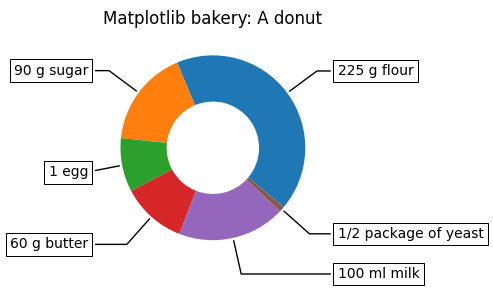

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))

recipe = ["225 g flour",
          "90 g sugar",
          "1 egg",
          "60 g butter",
          "100 ml milk",
          "1/2 package of yeast"]

data = [225, 90, 50, 60, 100, 5]

wedges, texts = ax.pie(data, wedgeprops=dict(width=0.5), startangle=-40)

bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    ax.annotate(recipe[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment, **kw)

ax.set_title("Matplotlib bakery: A donut")

plt.show()